# Parkinson's Disease Classifier
**ML Final Project**
***University of Padova***

Group 4:
- Larissa Pereira Moraes
- Zainab Fatima
- Yousra Dehgane

***

## Section 1: The Biological Problem

The question we are dealing with in this project is whether we can classify healthy individuals and Parkinson’s disease patients using voice biomarkers.

The following are the factors we are utilizing from our dataset to build the model:
- Input data: voice measurements
- Target variable: status 0 (healthy) and 1 (Parkinson's)
- One row represents: a voice recording
- One column represents: a feature

**Biological relevance:** Parkison's disease can cause vocal alterations in the early to mid stages of the disease, making it a possible factor to detect using a machine learning model as a low-cost diagnostic method (Xiu et al., 2024).

## Environment Setup

In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from ucimlrepo import fetch_ucirepo as fetch_uci_dataset

# import sys
# !{sys.executable} -m pip install ucimlrepo

np.random.seed(42)

### Section 2: Exploratory Data Analysis

Point 2.1
Report the number of samples and the number of variables.

Point 2.2
Identify which columns are metadata, which columns are input features, and which column is the target.


## Section 3: Determining the Machine Learning Task

**Target type:**  
The target variable is categorical and binary. The `status` variable has two classes: `0` for healthy individuals and `1` for Parkinson’s disease patients.

**Problem type:**  
This is a supervised binary classification problem. The goal is to predict whether a subject is healthy or has Parkinson’s disease using voice measurement features.

**Compatible models:**  
Appropriate models include Logistic Regression, k-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest, and other classification models.

**Models that are not appropriate and why:**  
Regression models are not appropriate because the target is not a continuous numerical value. For example, Linear Regression or Random Forest Regressor would predict continuous values, while this task requires predicting one of two classes: healthy or Parkinson’s disease.



## Section 4: Defining X and y
Point 4.1
Print the shape of X and explain what the two dimensions mean.

Point 4.2
Print the shape of y and explain what each element represents.

Point 4.3
If your dataset is a biological count or expression matrix, state whether you had to transpose it.

Point 4.4
Explain why the same dataset could lead to different Machine Learning (ML) tasks depending on the chosen target.


In [36]:
# Dataset 5 - Parkinsons

parkinson = fetch_uci_dataset(id=174) # fetched data from UCI API

X_parkinson_raw = parkinson.data.features.copy()  # copy of all the features
y_parkinson_raw = parkinson.data.targets.copy()   # copy of all the samples' targets

# printing features and targets
print("Feature columns:")
print(X_parkinson_raw.columns.tolist())

print("\nTarget columns:")
print(y_parkinson_raw.columns.tolist())

# getting the target column as a 1D array to be used in sklearn
# iloc[:, 0] flattens the 2D array into a 1D series for sklearn's fit(X,y)
y_parkinson = y_parkinson_raw.iloc[:, 0].copy()

# Remove non-numeric if present: column "name" 
X_parkinson = X_parkinson_raw.select_dtypes(include="number").copy()

# compiling the X and y into a new Panda's dataframe
parkinson_data = pd.concat(
    [X_parkinson, pd.Series(y_parkinson, name="target")],
    axis=1
)

print("X shape:", X_parkinson.shape)
print("y shape:", y_parkinson.shape)
print("Target values:")
print(pd.Series(y_parkinson).value_counts())

parkinson_data.head()

Feature columns:
['MDVP:Fo', 'MDVP:Fhi', 'MDVP:Flo', 'MDVP:Jitter', 'MDVP:Jitter', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Target columns:
['status']
X shape: (195, 22)
y shape: (195,)
Target values:
status
1    147
0     48
Name: count, dtype: int64


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,target
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


In [3]:
parkinson.variables

,name,role,type,demographic,description,units,missing_values
0,name,ID,Categorical,None,None,None,no
1,MDVP:Fo,Feature,Continuous,None,None,Hz,no
2,MDVP:Fhi,Feature,Continuous,None,None,Hz,no
3,MDVP:Flo,Feature,Continuous,None,None,Hz,no
4,MDVP:Jitter,Feature,Continuous,None,None,%,no
5,MDVP:Jitter,Feature,Continuous,None,None,Abs,no
6,MDVP:RAP,Feature,Continuous,None,None,None,no
7,MDVP:PPQ,Feature,Continuous,None,None,None,no
8,Jitter:DDP,Feature,Continuous,None,None,None,no
9,MDVP:Shimmer,Feature,Continuous,None,None,None,no




## Section 5: Dataset audit

Point 5.1
Is your dataset small, medium, or large relative to the number of features?

Point 5.2
If this is a classification task, are the classes balanced?

Point 5.3
Do the features need scaling? Justify your answer based on the models you plan to use.

Point 5.4
Identify one possible risk in this dataset, such as overfitting, class imbalance, outliers, or leakage.

### Column Duplicate Check 

The UCI dataset loaded via the API contains duplicated column labels for MDVP:Jitter and MDVP:Shimmer.

Although the dataset documentation defines 22 distinct features, two feature pairs appear under identical names in the loaded DataFrame.

Comparing our dataset with the same dataset available on Kaggle (see Supplementary Material), we observed that the feature definitions are consistent across sources. However, in the UCI API-loaded version used in this analysis, two feature pairs (MDVP:Jitter(%);MDVP:Jitter(abs) and MDVP:Shimmer;MDVP:Shiimer(db))) appear as duplicated columns with identical values. 

In [4]:
# verifying which columns are duplicates
print(X_parkinson.columns[X_parkinson.columns.duplicated()])

Index(['MDVP:Jitter', 'MDVP:Shimmer'], dtype='object')


**Verifying MDVP:Jitter**

In [5]:
# check if column is duplicate
X_parkinson.iloc[:, 3].head()   # first MDVP:Jitter

0    0.00784
1    0.00968
2    0.01050
3    0.00997
4    0.01284
Name: MDVP:Jitter, dtype: float64

In [6]:
(X_parkinson.iloc[:, 3] == X_parkinson.iloc[:, 4]).all()

np.True_

In [7]:
jitter_cols = X_parkinson.loc[:, "MDVP:Jitter"]

# print(jitter_cols.head())
print((jitter_cols.iloc[:, 0] == jitter_cols.iloc[:, 1]).all())

True


**Verifying MDVP:Shimmer**

In [8]:
shimmer_cols = X_parkinson.loc[:, "MDVP:Shimmer"]

# print(jitter_cols.head())
print((shimmer_cols.iloc[:, 0] == shimmer_cols.iloc[:, 1]).all())

True


**Dropping Duplicate Columns**

Duplicate features were removed because they provide no additional information and may bias some models or inflate feature importance.

In [9]:
# Dropping duplicate columns
X_parkinson_clean = X_parkinson.T.drop_duplicates().T
X_parkinson_clean.shape

(195, 20)

In [10]:
# sanity check for duplicates
print(X_parkinson_clean.columns[X_parkinson_clean.columns.duplicated()])

Index([], dtype='object')


### Missing Values Check

In [11]:
missing_features = X_parkinson_clean.isnull().sum()
print("\nMissing values in features:")
print(missing_features)
print(f"Total missing: {missing_features.sum()}")

# Check for missing values in target
missing_target = y_parkinson.isnull().sum()
print(f"\nMissing values in target: {missing_target}")


Missing values in features:
MDVP:Fo         0
MDVP:Fhi        0
MDVP:Flo        0
MDVP:Jitter     0
MDVP:RAP        0
MDVP:PPQ        0
Jitter:DDP      0
MDVP:Shimmer    0
Shimmer:APQ3    0
Shimmer:APQ5    0
MDVP:APQ        0
Shimmer:DDA     0
NHR             0
HNR             0
RPDE            0
DFA             0
spread1         0
spread2         0
D2              0
PPE             0
dtype: int64
Total missing: 0

Missing values in target: 0


### Class Balance Check

Due to class imbalance, model evaluation will prioritize recall and F1-score over accuracy, as false negatives (failing to detect Parkinson’s disease) are clinically more critical than false positives.

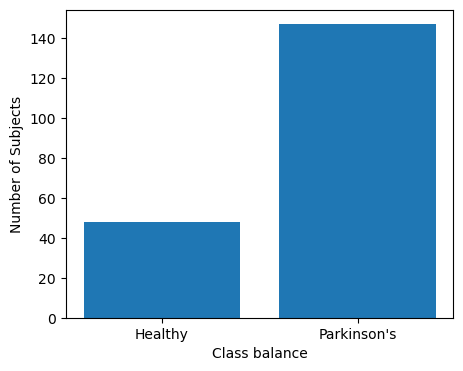

In [12]:
# Class Balance
labels = ["Healthy", "Parkinson's"]
counts = [np.sum(y_parkinson == 0), np.sum(y_parkinson == 1)]

plt.figure(figsize=(5, 4))
plt.bar(labels, counts)
plt.ylabel("Number of Subjects")
plt.xlabel("Class balance")
plt.show()

**Visualize Distribution of Features**

Visual inspection of feature distributions shows that HNR provides strong separation between classes, with healthy subjects exhibiting higher values. RPDE and DFA show partial but less distinct separation, suggesting they contribute to classification in combination with other features rather than individually.

In [13]:
parkinson_data["status"] = y_parkinson

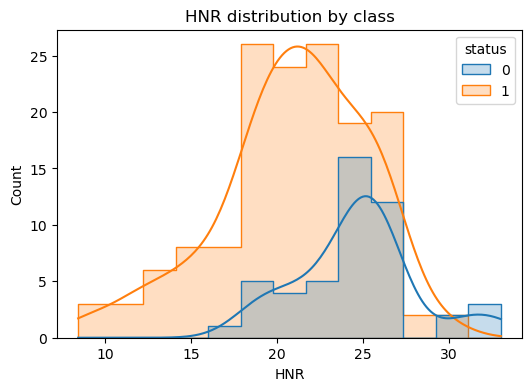

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="HNR", hue="status", kde=True, element="step")
plt.title("HNR distribution by class")
plt.show()

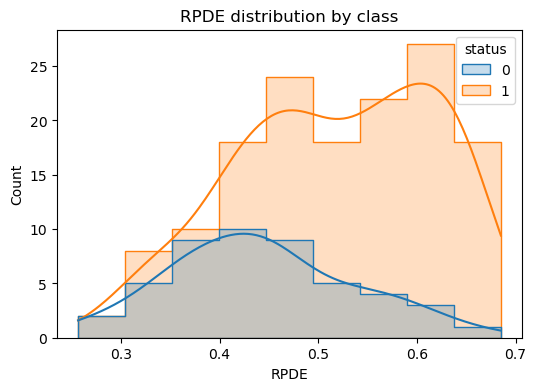

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="RPDE", hue="status", kde=True, element="step")
plt.title("RPDE distribution by class")
plt.show()

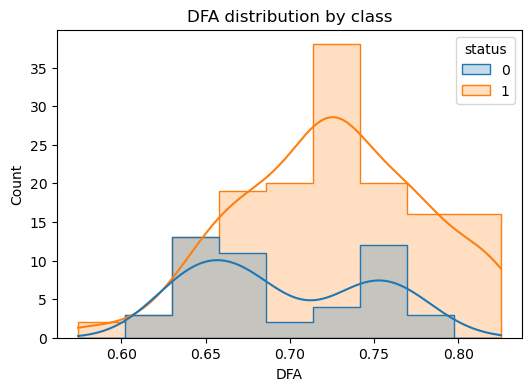

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="DFA", hue="status", kde=True, element="step")
plt.title("DFA distribution by class")
plt.show()

In [17]:
# sns.pairplot(parkinson_data[["HNR", "RPDE", "DFA", "status"]], hue="status")

**Point 5.1**
Is your dataset small, medium, or large relative to the number of features?

Our dataset has 195 samples and 20 features (after removing duplicates), giving a ratio of 9.75 samples per feature. This is considered a SMALL dataset. With fewer than 10 samples per feature, we need to be careful about overfitting.

**Point 5.2**
If this is a classification task, are the classes balanced?

No, the classes are imbalanced with 147 Parkinson's cases (75%) and 48 healthy cases (25%), resulting in a 3:1 class ratio that could bias the model toward predicting the majority class.


**Point 5.3**
Do the features need scaling? Justify your answer based on the models you plan to use.

Yes, scaling is necessary because Logistic Regression relies on distance metrics and requires features on the same scale, while Random Forest (tree-based) doesn't require scaling but won't be harmed by it, so we scale for consistency.


**Point 5.4**
Identify one possible risk in this dataset, such as overfitting, class imbalance, outliers, or leakage.

The primary risk is class imbalance: with 75% of samples being Parkinson's cases, a naive model could achieve 75% accuracy by predicting everyone as Parkinson's, making it clinically useless for detecting healthy individuals.



## Section 6: Baseline Model Selection

Point 6.1
Choose the simplest reasonable baseline for your task.

Point 6.2
Explain why this baseline is appropriate.

Point 6.3
Evaluate the baseline on the validation set.

Point 6.4
State what performance a more complex model must beat to be useful.

#
## Section 7: Candidate Models

Baseline model: Logistic Regression

Logistic Regression is the baseline model because this is a binary classification task. The target variable is `status`, where 0 represents healthy subjects and 1 represents Parkinson's disease. Logistic 

Candidate model 1: Random Forest Classifier

Why this model:
Random Forest is suitable because it can capture non-linear relationships between the voice features and Parkinson's disease status. This is useful because biomedical voice measurements may interact in complex ways.

Expected advantage:
It does not require feature scaling and can model non-linear patterns. It also provides feature importance.

Expected risk:
Random Forest can overfit, especially because the dataset is small. If the trees are too deep, the model may memorize the training data instead of generalizing well.

Candidate model 2: Support Vector Machine

Why this model:
Support Vector Machine is useful for small biomedical datasets because it tries to find a strong decision boundary between classes. Using an RBF kernel allows the model to capture non-linear separation between healthy and Parkinson's samples.

Expected advantage:
It can perform well on small datasets and can create non-linear decision boundaries.

Expected risk:
It requires feature scaling and is less interpretable than Logistic Regression. Its performance also depends strongly on hyperparameters such as `C` and `gamma`.

Candidate model 3, optional: K-Nearest Neighbors

Why this model:
KNN is a simple distance-based model that classifies a sample based on the labels of its nearest neighbors. It is useful as an additional comparison model.
Expected advantage:
It is simple and intuitive. It can work well if similar voice profiles belong to the same class.

Expected risk:
It requires feature scaling and may perform poorly when there are many features or noisy measurements. It can also be sensitive to the value of `n_neighbors`.

Reflection points for Section 7

Point 7.1
For each candidate model, state whether feature scaling is required or recommended.

Logistic Regression:
Feature scaling is recommended because the model uses coefficients and optimization. Features with larger numerical ranges can dominate the model if scaling is not applied.

Random Forest:
Feature scaling is not required because tree-based models split features using thresholds. The scale of the feature does not affect how the tree makes splits.

Support Vector Machine:
Feature scaling is required because SVM is distance-based. If features are on different scales, the model may give too much importance to features with larger values.

K-Nearest Neighbors:
Feature scaling is required because KNN uses distances between samples. Without scaling, features with larger numeric ranges would dominate the distance calculation.

Point 7.2
For each candidate model, state one important hyperparameter.

Logistic Regression:
An important hyperparameter is `C`, which controls regularization strength. Smaller values of `C` apply stronger regularization.

Random Forest:
An important hyperparameter is `max_depth`, which controls how deep each tree can grow. Deeper trees can fit the training data more closely but may overfit.

Support Vector Machine:
An important hyperparameter is `C`, which controls the trade-off between a wider margin and classification errors. Another important hyperparameter for the RBF kernel is `gamma`.

K-Nearest Neighbors:
An important hyperparameter is `n_neighbors`, which controls how many nearby samples are used to classify a new sample.
Point 7.3
Rank your models from most interpretable to least interpretable.

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest
4. Support Vector Machine with RBF kernel

Logistic Regression is the most interpretable because each feature has a coefficient. KNN is simple to understand but does not produce a clear formula. Random Forest can provide feature importance, but the full model is harder to interpret. SVM with RBF kernel is the least interpretable because the decision boundary is complex.

Point 7.4
Which model do you expect to overfit most easily? Why?

Random Forest is expected to overfit most easily if the trees are allowed to become too deep. This is because each tree can learn very specific patterns from the training data, especially in a small dataset. SVM with an RBF kernel can also overfit if `C` or `gamma` are not well controlled. Logistic Regression is less likely to overfit because it is simpler, but it may underfit if the real relationship between the voice features and Parkinson's disease is non-linear.


### Section 8: Train, Validation, and Test Strategy

Point 8.1
Create a train, validation, and test split.

We split the data using stratified random sampling: first into 80% train+validation and 20% test (maintaining class proportions), then split the train+validation into 75% training and 25% validation to ensure each set represents the original class distribution.


Point 8.2
Report the number of samples in each split.

The dataset is split into 117 training samples, 39 validation samples, and 39 test samples, with the 117 training samples used to fit the model, 39 validation samples to tune hyperparameters, and 39 test samples held out for final evaluation.


Point 8.3
If classification, report class balance in each split.

Each split maintains the original 75:25 class ratio: training set has 88 Parkinson's and 28 healthy cases, validation set has 29 Parkinson's and 10 healthy cases, and test set has 29 Parkinson's and 9 healthy cases, preserving class proportions across all splits.


Point 8.4
Explain why the test set should not be used to choose the model.

The test set must remain untouched during model selection because using it to compare models would allow the model to implicitly learn from the test data, inflating performance estimates and resulting in overly optimistic metrics that won't generalize to truly new data in practice.



In [18]:
# Section 8 - Train, validation, and test split template

# For classification, use stratify=y.
X_train_full, X_test, y_train_full, y_test = train_test_split(
     X_parkinson_clean,
     y_parkinson,
     test_size=0.20,
     random_state=42,
     stratify=y_parkinson
 )

X_train, X_val, y_train, y_val = train_test_split(
     X_train_full,
     y_train_full,
     test_size=0.25,  
     random_state=42,
     stratify=y_train_full
 )

# Shape for test, validation, and training sets
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_test_full shape: {X_test.shape}")
print(f"Training class counts: {np.unique(y_train, return_counts=True)}")
print(f"Test class counts: {np.unique(y_test, return_counts=True)}")

X_train_full shape: (156, 20)
X_test_full shape: (39, 20)
Training class counts: (array([0, 1]), array([28, 89]))
Test class counts: (array([0, 1]), array([10, 29]))


**Feature Scaling**

In [19]:
# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

train_pred = model.predict(X_train_scaled)
val_pred = model.predict(X_val_scaled)

In [20]:
# Comparing with unbalanced dataset
model_unbalanced = LogisticRegression(max_iter=1000)
model_unbalanced.fit(X_train_scaled, y_train)
y_pred_unbalanced = model_unbalanced.predict(X_val_scaled)

### Section 9: Comparing Models: Logistic Regression vs. Random Forest

Primary metric:
F1-Score is the primary metric because it balances precision and recall, providing a single score that accounts for class imbalance and prevents the model from simply predicting the majority class to achieve high accuracy.

Secondary metrics:
Recall (sensitivity), Precision, and Confusion Matrix are secondary metrics because they detail how many sick patients are correctly identified (recall), how many predicted positives are actually sick (precision), and the breakdown of all prediction types.

Why these metrics are appropriate:
These metrics are appropriate because the dataset is imbalanced (75% Parkinson's, 25% healthy), making accuracy misleading, and for medical diagnosis, both false alarms (precision) and missed cases (recall) matter, but recall is prioritized since missing a disease case is clinically more critical than a false alarm.

Which error is more biologically problematic, false positives or false negatives?

Why:
False negatives directly harm patient outcomes by delaying or preventing treatment, whereas false positives only result in unnecessary follow-up testing; in medical diagnosis, the cost of missing a disease is always higher than the cost of additional testing, especially for a progressive neurological condition like 
Parkinson's disease.


In [22]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, confusion_matrix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_lr = model.predict(X_val_scaled)


rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

#Both models trained

# PRIMARY METRIC: F1-Score
f1_lr = f1_score(y_val, y_pred_lr)
f1_rf = f1_score(y_val, y_pred_rf)
print(f"  Logistic Regression: {f1_lr:.4f}")
print(f"  Random Forest:       {f1_rf:.4f}")

# SECONDARY METRICS
metrics_lr = {
    'Recall': recall_score(y_val, y_pred_lr),
    'Precision': precision_score(y_val, y_pred_lr),
    'Accuracy': accuracy_score(y_val, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_val, model.predict_proba(X_val_scaled)[:, 1])
}

metrics_rf = {
    'Recall': recall_score(y_val, y_pred_rf),
    'Precision': precision_score(y_val, y_pred_rf),
    'Accuracy': accuracy_score(y_val, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
}

comparison_df = pd.DataFrame({
    'Metric': list(metrics_lr.keys()),
    'Logistic Regression': list(metrics_lr.values()),
    'Random Forest': list(metrics_rf.values())
})
print(comparison_df.to_string(index=False))

# CONFUSION MATRIX 
#logictic regression 
cm_lr = confusion_matrix(y_val, y_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
print(f"  TN: {tn_lr}, FP: {fp_lr}, FN: {fn_lr}, TP: {tp_lr}")

#random forest
cm_rf = confusion_matrix(y_val, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"  TN: {tn_rf}, FP: {fp_rf}, FN: {fn_rf}, TP: {tp_rf}")



  Logistic Regression: 0.8929
  Random Forest:       0.8772
   Metric  Logistic Regression  Random Forest
   Recall             0.862069       0.862069
Precision             0.925926       0.892857
 Accuracy             0.846154       0.820513
  ROC-AUC             0.886207       0.934483
  TN: 8, FP: 2, FN: 4, TP: 25
  TN: 7, FP: 3, FN: 4, TP: 25


In [26]:
# Section 9 - Model comparison

model_results = []

model_results.append({
    "model": "Logistic Regression (baseline)",
    "train_score": f1_score(y_train, train_pred),
    "validation_score": f1_score(y_val, val_pred),
    "main_metric": f1_score(y_val, val_pred),
    "notes": "Scaled + class_weight=balanced"
})

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    max_depth=5
)

rf.fit(X_train, y_train)

train_pred_rf = rf.predict(X_train)
val_pred_rf = rf.predict(X_val)

model_results.append({
    "model": "Random Forest",
    "train_score": f1_score(y_train, train_pred_rf),
    "validation_score": f1_score(y_val, val_pred_rf),
    "main_metric": f1_score(y_val, val_pred_rf),
    "notes": "No scaling needed, tree-based model"
})

In [25]:
results_df = pd.DataFrame(model_results)
results_df

,model,train_score,validation_score,main_metric,notes
0,Logistic Regression (baseline),0.886228,0.892857,0.892857,Scaled + class_weight=balanced
1,Random Forest,1.000000,0.915254,0.915254,"No scaling needed, tree-based model"


## Section 10: Train and compare models

### Point 10.1

The baseline model is Logistic Regression. It is simple, interpretable, and uses class weights to handle class imbalance. The alternative model is Random Forest, which is more flexible and can capture non-linear feature interactions. Both models were trained using the same train/validation/test split with stratification to preserve the class distribution.

### Point 10.2

A summary table was created to compare model performance using F1-score, recall, precision, accuracy, and ROC-AUC. Logistic Regression achieved a validation F1-score of 0.8929, while Random Forest achieved a validation F1-score of 0.8772.

### Point 10.3

Based on validation F1-score, Logistic Regression performs best on the validation data. It achieved a slightly higher F1-score than Random Forest. Logistic Regression also had higher validation precision, meaning it produced fewer false alarms.

### Point 10.4

The best-performing model is also the most interpretable model. Logistic Regression is the most interpretable because it provides feature coefficients, which show the direction and strength of each feature’s contribution to the prediction. Therefore, Logistic Regression is selected as the best model based on both validation performance and interpretability.



In [34]:
#10.1
# Prepare data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#train models

# Baseline: Logistic Regression
baseline_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained (BASELINE)")

# Alternative: Random Forest
alternative_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=5,
    random_state=42, class_weight="balanced"
)
alternative_model.fit(X_train, y_train)
print("Random Forest trained (ALTERNATIVE)")

# 10.2
# Predictions
y_val_pred_lr = baseline_model.predict(X_val_scaled)
y_val_pred_rf = alternative_model.predict(X_val)
y_test_pred_lr = baseline_model.predict(X_test_scaled)
y_test_pred_rf = alternative_model.predict(X_test)

# Metrics
metrics = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Validation F1': [f1_score(y_val, y_val_pred_lr), f1_score(y_val, y_val_pred_rf)],
    'Validation Recall': [recall_score(y_val, y_val_pred_lr), recall_score(y_val, y_val_pred_rf)],
    'Validation Precision': [precision_score(y_val, y_val_pred_lr), precision_score(y_val, y_val_pred_rf)],
    'Validation Accuracy': [accuracy_score(y_val, y_val_pred_lr), accuracy_score(y_val, y_val_pred_rf)],
    'Validation ROC-AUC': [
        roc_auc_score(y_val, baseline_model.predict_proba(X_val_scaled)[:, 1]),
        roc_auc_score(y_val, alternative_model.predict_proba(X_val)[:, 1])
    ],
    'Test F1': [f1_score(y_test, y_test_pred_lr), f1_score(y_test, y_test_pred_rf)],
    'Test Recall': [recall_score(y_test, y_test_pred_lr), recall_score(y_test, y_test_pred_rf)],
    'Test ROC-AUC': [
        roc_auc_score(y_test, baseline_model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, alternative_model.predict_proba(X_test)[:, 1])
    ]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df.to_string(index=False))

# 10.3
val_f1_lr = f1_score(y_val, y_val_pred_lr)
val_f1_rf = f1_score(y_val, y_val_pred_rf)

print(f"  Logistic Regression: F1 = {val_f1_lr:.4f}")
print(f"  Random Forest:       F1 = {val_f1_rf:.4f}")

if val_f1_rf > val_f1_lr:
    print(f"\n  BEST MODEL: Random Forest (F1 = {val_f1_rf:.4f})")
    print(f"    Recall: {recall_score(y_val, y_val_pred_rf):.4f} (catches disease cases)")
    print(f"    Precision: {precision_score(y_val, y_val_pred_rf):.4f} (avoids false alarms)")
else:
    print(f"\n  BEST MODEL: Logistic Regression (F1 = {val_f1_lr:.4f})")
    print(f"    Recall: {recall_score(y_val, y_val_pred_lr):.4f} (catches disease cases)")
    print(f"    Precision: {precision_score(y_val, y_val_pred_lr):.4f} (avoids false alarms)")

## 10.4 - Final interpretation: performance vs interpretability

most_interpretable_model = "Logistic Regression"

if val_f1_rf > val_f1_lr:
    best_performance_model = "Random Forest"
    best_validation_f1 = val_f1_rf
else:
    best_performance_model = "Logistic Regression"
    best_validation_f1 = val_f1_lr

print(f"\nBest performance model based on validation F1: {best_performance_model}")
print(f"Best validation F1-score: {best_validation_f1:.4f}")

print(f"\nMost interpretable model: {most_interpretable_model}")
print("Reason: Logistic Regression provides feature coefficients, so it is easier to interpret.")

print("\nFinal conclusion:")
if best_performance_model == most_interpretable_model:
    print("Logistic Regression is selected because it has the best validation F1-score and is also the most interpretable model.")
else:
    print(f"{best_performance_model} has the best validation F1-score.")
    print("However, Logistic Regression is more interpretable.")
    print("This shows a trade-off between predictive performance and interpretability.")

Logistic Regression trained (BASELINE)
Random Forest trained (ALTERNATIVE)
              Model  Validation F1  Validation Recall  Validation Precision  Validation Accuracy  Validation ROC-AUC  Test F1  Test Recall  Test ROC-AUC
Logistic Regression       0.892857           0.862069              0.925926             0.846154            0.886207 0.823529     0.724138      0.931034
      Random Forest       0.877193           0.862069              0.892857             0.820513            0.934483 0.872727     0.827586      0.927586
  Logistic Regression: F1 = 0.8929
  Random Forest:       F1 = 0.8772

  BEST MODEL: Logistic Regression (F1 = 0.8929)
    Recall: 0.8621 (catches disease cases)
    Precision: 0.9259 (avoids false alarms)

Best performance model based on validation F1: Logistic Regression
Best validation F1-score: 0.8929

Most interpretable model: Logistic Regression
Reason: Logistic Regression provides feature coefficients, so it is easier to interpret.

Final conclusion:
Logi

## Section 11: Diagnostic Plots and Learning Curves

Point 11.1
Generate at least one diagnostic plot appropriate for your task.

The diagnostic plots generated are a learning curve and a validation confusion matrix for the selected Logistic Regression model. The learning curve is appropriate because it compares training and validation F1-score as the training set size increases. The confusion matrix is useful because it shows true positives, true negatives, false positives, and false negatives. The model produced 8 TN, 25 TP, 2 FP, and 4 FN.

Point 11.2
State whether your model shows signs of high bias, high variance, or neither.

The model shows neither severe high bias nor severe high variance. The final training F1-score is 0.8865 and the final validation F1-score is 0.8529, giving a small gap of 0.0336. Since both scores are reasonably high and close to each other, the model generalizes well without clear underfitting or overfitting.

Point 11.3
Propose one change you would try next based on the diagnostic plot.

Based on the diagnostic plot, one change I would try next is tuning the regularization strength of Logistic Regression using different values of C. Since the model does not show severe overfitting, the goal would be to check whether slightly weaker or stronger regularization can improve validation F1-score without increasing the train-validation gap.

Point 11.4
Explain why validation performance is more informative than training performance for model choice.

Validation performance is more informative than training performance because it measures how well the model generalizes to unseen data. Training performance only shows how well the model fits examples it has already seen. 

Selected model for Section 11 diagnostics: Logistic Regression
Validation F1-score from Section 10: 0.8929


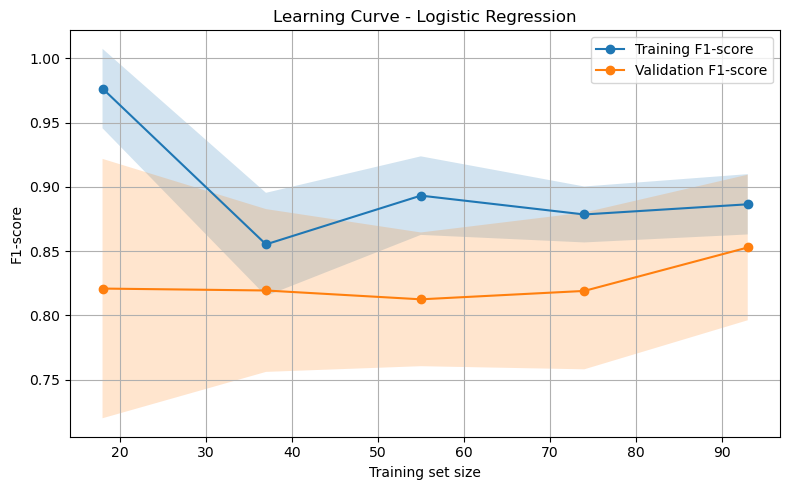

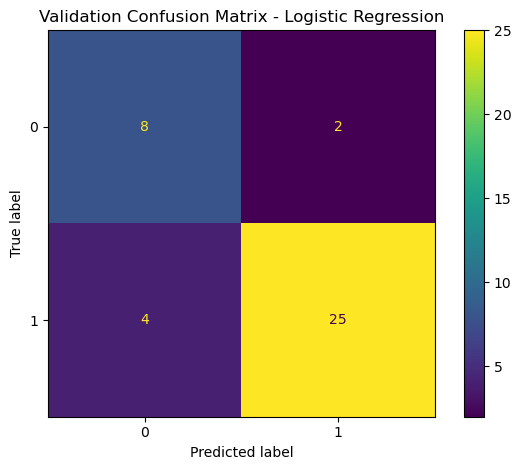


Diagnostic summary
Final training F1 from learning curve:   0.8865
Final validation F1 from learning curve: 0.8529
Train-validation gap:                    0.0336
Diagnosis: no severe high bias or high variance


In [ ]:
# Section 11 - Diagnostic Plots and Learning Curves

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay


# 1. Select model based on validation F1-score from Section 10


if val_f1_lr >= val_f1_rf:
    selected_model_name = "Logistic Regression"
    selected_val_f1 = val_f1_lr

    selected_estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("logistic_regression", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ])

    fitted_model_for_cm = baseline_model
    X_val_for_cm = X_val_scaled

else:
    selected_model_name = "Random Forest"
    selected_val_f1 = val_f1_rf

    selected_estimator = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced"
    )

    fitted_model_for_cm = alternative_model
    X_val_for_cm = X_val

print(f"Selected model for Section 11 diagnostics: {selected_model_name}")
print(f"Validation F1-score from Section 10: {selected_val_f1:.4f}")

# 2. Learning curve diagnostic plot


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=selected_estimator,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, marker="o", label="Training F1-score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1-score")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel("Training set size")
plt.ylabel("F1-score")
plt.title(f"Learning Curve - {selected_model_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 3. Confusion matrix diagnostic plot

ConfusionMatrixDisplay.from_estimator(
    fitted_model_for_cm,
    X_val_for_cm,
    y_val
)

plt.title(f"Validation Confusion Matrix - {selected_model_name}")
plt.tight_layout()
plt.show()


# 4. Bias-variance diagnostic summary


final_train_f1 = train_mean[-1]
final_val_f1 = val_mean[-1]
gap = final_train_f1 - final_val_f1

print("\nDiagnostic summary")
print(f"Final training F1 from learning curve:   {final_train_f1:.4f}")
print(f"Final validation F1 from learning curve: {final_val_f1:.4f}")
print(f"Train-validation gap:                    {gap:.4f}")

if final_train_f1 < 0.75 and final_val_f1 < 0.75:
    diagnosis = "high bias / underfitting"
elif gap > 0.10:
    diagnosis = "high variance / overfitting"
else:
    diagnosis = "no severe high bias or high variance"

print(f"Diagnosis: {diagnosis}")

## Section 12

## Reflection points for Section 12

### Chosen final model

The final selected model is Logistic Regression.

### Why this model

Logistic Regression was selected because it achieved the best validation F1-score in the current model comparison. It obtained a validation F1-score of 0.8929, which was higher than the Random Forest validation F1-score of 0.8772. The diagnostic learning curve also showed no severe high bias or high variance, with a small train-validation gap of 0.0336. This suggests that the model generalizes reasonably well.

### Why not the baseline only

In this project, Logistic Regression was used as the baseline model, but it was not selected only because it was the baseline. It was selected because it performed well on validation data, showed stable diagnostic behavior, and is interpretable. Therefore, the final choice is supported by performance and not only by simplicity.

### Why not the more complex alternative

Random Forest was not selected because it had a lower validation F1-score than Logistic Regression in the current comparison. Although Random Forest is more flexible and can capture non-linear patterns, it is also less interpretable and may have a higher risk of overfitting, especially with a small dataset. Since the performance advantage was not present on validation data, the simpler and more interpretable Logistic Regression model was preferred.

### Main evidence supporting this choice

The main evidence is the validation F1-score, where Logistic Regression achieved 0.8929 compared with 0.8772 for Random Forest. The learning curve also supported this choice because the training and validation F1-scores were reasonably close, suggesting no severe overfitting. The confusion matrix showed that Logistic Regression correctly classified most validation samples, with 8 true negatives, 25 true positives, 2 false positives, and 4 false negatives.

### Main limitation

The main limitation is that Logistic Regression is a linear model. It may not capture complex non-linear relationships between the voice features and Parkinson’s disease status. Also, the dataset is relatively small and imbalanced, so the model should be validated on more data before being trusted in a real clinical setting.





## Section 13

   Metric  Test performance
 F1-score          0.823529
   Recall          0.724138
Precision          0.954545
 Accuracy          0.769231
  ROC-AUC          0.927586

Classification report:
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.95      0.72      0.82        29

    accuracy                           0.77        39
   macro avg       0.74      0.81      0.75        39
weighted avg       0.85      0.77      0.78        39



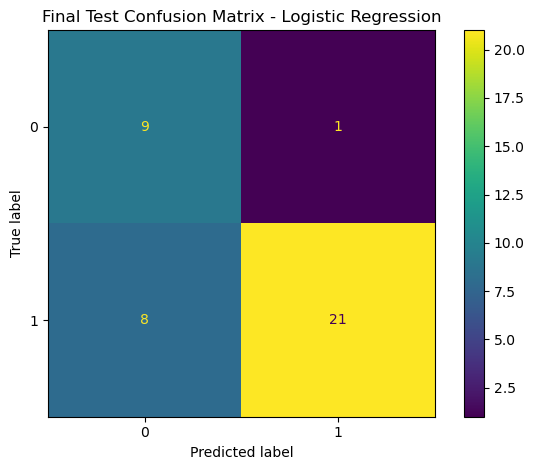

In [31]:
# Section 13 - Final Test Evaluation

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score, precision_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

# Combine training and validation data after final model selection
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Final selected model: Logistic Regression
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Fit final model on training + validation data
final_model.fit(X_train_full, y_train_full)

# Evaluate once on the test set
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Test metrics
test_f1 = f1_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

test_results = pd.DataFrame({
    "Metric": ["F1-score", "Recall", "Precision", "Accuracy", "ROC-AUC"],
    "Test performance": [test_f1, test_recall, test_precision, test_accuracy, test_roc_auc]
})

print(test_results.to_string(index=False))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("Final Test Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

## Reflection points of section 13 

Point 13.1

The final Logistic Regression model was evaluated once on the test set after model selection. The test F1-score was 0.8235, with recall of 0.7241, precision of 0.9545, accuracy of 0.7692, and ROC-AUC of 0.9276. The confusion matrix showed 9 true negatives, 21 true positives, 1 false positive, and 8 false negatives.

Point 13.2

The validation F1-score was 0.8929, while the final test F1-score was 0.8235. Therefore, test performance was lower than validation performance. This suggests that the validation result was somewhat optimistic, although the model still achieved a reasonable test F1-score and a strong ROC-AUC of 0.9276.

Point 13.3

A possible explanation for the lower test performance is that the dataset is small and imbalanced. The test set may contain a slightly different distribution of healthy and Parkinson’s samples compared with the validation set. Also, model choices were made using validation performance, so the validation score can be more optimistic than the final unseen test score.

Point 13.4

I would not fully trust this model for a strong biological conclusion yet. The model shows useful predictive performance, but it missed 8 Parkinson’s cases on the test set. In a biological or medical context, these false negatives are important. Therefore, the model could support further investigation, but it should be validated on a larger independent dataset before making strong biological conclusions.

## Section 14 — Biological interpretation


In [32]:
# Section 14 - Biological interpretation

import pandas as pd
import numpy as np

# Get the Logistic Regression model from the final pipeline
log_reg = final_model.named_steps["logistic_regression"]

# Get feature names
feature_names = X_train.columns

# Get coefficients
coefficients = log_reg.coef_[0]

# Create coefficient table
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute coefficient": np.abs(coefficients)
})

# Sort by strongest signals
coef_df = coef_df.sort_values(by="Absolute coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Absolute coefficient
16,spread1,1.211487,1.211487
10,MDVP:APQ,1.110250,1.110250
19,PPE,0.739081,0.739081
18,D2,0.586283,0.586283
3,MDVP:Jitter,-0.553600,0.553600
17,spread2,0.472582,0.472582
7,MDVP:Shimmer,0.440291,0.440291
5,MDVP:PPQ,-0.417476,0.417476
9,Shimmer:APQ5,0.352669,0.352669
4,MDVP:RAP,0.349620,0.349620


### Reflection points for Section 14

**Point 14.1:**  
The strongest model signals are spread1, MDVP:APQ, PPE, D2, MDVP:Jitter, spread2, MDVP:Shimmer, MDVP:PPQ, Shimmer:APQ5, and MDVP:RAP. These were identified from the largest absolute Logistic Regression coefficients.

**Point 14.2:**  
These signals are biologically plausible because Parkinson’s disease can affect speech motor control, and many of these features measure voice instability, perturbation, or nonlinear vocal patterns.

**Point 14.3:**  
The model does not prove causality. It does not show that these voice features cause Parkinson’s disease; it only shows that they are useful for prediction in this dataset.

**Point 14.4:**  
A useful follow-up would be external validation on a larger independent dataset to check whether the same features remain important and whether the model generalizes to new subjects.

## Section 15 — Limitations

The main limitation is the small dataset size. The dataset contains only 195 samples, so the model may not generalize well to a larger or more diverse population.

Another limitation is class imbalance. There are more Parkinson’s cases than healthy controls, which can affect model learning and evaluation. Although class weighting and F1-score were used to reduce this problem, imbalance is still a concern.

The model also missed 8 Parkinson’s cases on the final test set. These false negatives are important in a medical context because they represent diseased subjects predicted as healthy.

Finally, the features are voice measurements, not direct biological measurements. Therefore, the model can suggest useful predictive patterns, but it cannot prove a biological mechanism or causality.

A larger independent dataset would be needed to confirm the model performance and validate whether the same voice features remain important.